In [961]:
import pandas as pd

df = pd.read_csv('./employee_data.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   34        No  Travel_Frequently        702  Research & Development   
1   38        No      Travel_Rarely        833  Research & Development   
2   51        No      Travel_Rarely        833  Research & Development   
3   60        No      Travel_Rarely       1179                   Sales   
4   23        No      Travel_Rarely        571  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                16          4  Life Sciences              1             838   
1                18          3        Medical              1            1766   
2                 1          3  Life Sciences              1             353   
3                16          4      Marketing              1             732   
4                12          2          Other              1            1982   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [962]:
print(df.head()['StandardHours'].nunique())
print(df.head()['Over18'].nunique())
print(df.head()['EmployeeCount'].nunique())

df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount'])

1
1
1


In [963]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [964]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['overtime_x_experience'] = df['OverTime'].map({'Yes': 1, 'No': -1}) * df['YearsAtCompany']

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,overtime_x_experience
0,34,0,Travel_Frequently,702,Research & Development,16,4,Life Sciences,838,3,...,3,0,6,3,3,5,2,1,3,-5
1,38,0,Travel_Rarely,833,Research & Development,18,3,Medical,1766,2,...,3,1,15,2,3,1,0,1,0,1
2,51,0,Travel_Rarely,833,Research & Development,1,3,Life Sciences,353,3,...,2,0,1,0,2,1,0,0,0,-1
3,60,0,Travel_Rarely,1179,Sales,16,4,Marketing,732,1,...,4,0,10,1,3,2,2,2,2,-2
4,23,0,Travel_Rarely,571,Research & Development,12,2,Other,1982,4,...,3,0,5,6,4,5,2,1,4,-5


In [965]:
churnCount = df['Attrition'].value_counts()
churnCount

Attrition
0    1048
1     201
Name: count, dtype: int64

In [966]:
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)
print(df.columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'overtime_x_experience',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Female', 'Gender_Male', '

In [967]:
df.corrwith(df['Attrition']).sort_values(ascending=False)

Attrition                            1.000000
OverTime_Yes                         0.223517
MaritalStatus_Single                 0.171914
JobRole_Sales Representative         0.142064
overtime_x_experience                0.140095
JobRole_Laboratory Technician        0.128079
BusinessTravel_Travel_Frequently     0.113758
DistanceFromHome                     0.085921
Department_Sales                     0.073414
EducationField_Technical Degree      0.050831
EducationField_Marketing             0.050323
EducationField_Human Resources       0.049799
NumCompaniesWorked                   0.046480
JobRole_Human Resources              0.034500
Gender_Male                          0.024300
JobRole_Sales Executive              0.018855
Department_Human Resources           0.015897
MonthlyRate                          0.015846
PerformanceRating                    0.013731
EmployeeNumber                       0.000162
PercentSalaryHike                    0.000026
EducationField_Life Sciences      

In [968]:
from sklearn.model_selection import train_test_split

df = df.drop(['EmployeeNumber', 'PercentSalaryHike'], axis=1)

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [969]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

os = SMOTE(random_state=42)
X_train_res, y_train_res = os.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

model = XGBClassifier(
    random_state=42,
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
)
model.fit(X_train_res, y_train_res)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

Attrition
0    834
1    834
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       214
           1       0.71      0.47      0.57        36

    accuracy                           0.90       250
   macro avg       0.81      0.72      0.75       250
weighted avg       0.89      0.90      0.89       250



<Axes: >

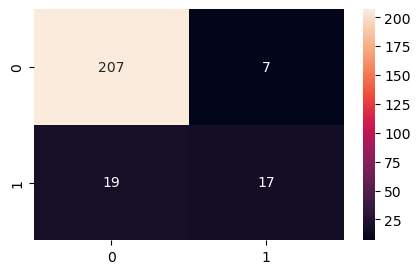

In [970]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')